In [ ]:
# STEP 1 : Check GPU

!nvidia-smi


Wed Sep  9 17:12:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# STEP 2 : Install Required Libraries

!pip install -q ultralytics roboflow albumentations

import os
import cv2
import albumentations as A
from tqdm import tqdm
import matplotlib.pyplot as plt

from ultralytics import YOLO
import ultralytics

from roboflow import Roboflow

from IPython.display import Image, display

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 135.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 8.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [ ]:
# STEP 4 : Verify Installation

ultralytics.checks()


Ultralytics 8.4.145 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.4/112.6 GB disk)


In [ ]:
# STEP 5 : Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# STEP 6 : Define Paths
# NEW_DIR is the ONE new folder this notebook creates and uses.
# To revert everything: delete NEW_DIR ("Big Dataset Model") + this notebook.
import os
MAIN_PROJECT_DIR = "/content/drive/MyDrive/Diploma Major Project(DCSE691)"

NEW_DIR = os.path.join(MAIN_PROJECT_DIR, "updated Model with 61 classes")
NEW_DATASET_DIR = os.path.join(NEW_DIR, "dataset")

os.makedirs(NEW_DIR, exist_ok=True)
print("New model folder:", NEW_DIR)


New model folder: /content/drive/MyDrive/Diploma Major Project(DCSE691)/updated Model with 61 classes


In [ ]:
# STEP 7 : Download the Dataset from Roboflow (only runs once)
# Get your free API key from: https://app.roboflow.com/settings/api
# Dataset: "Traffic Signs and Traffic Lights" (4254 images, 47 classes)
# https://universe.roboflow.com/traffic-signs-detection-aojvk/traffic-signs-and-traffic-lights

ROBOFLOW_API_KEY = "mvuHz8eVHof37iaDjF6F"  # <-- paste your key here

if not os.path.exists(NEW_DATASET_DIR):
    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    project = rf.workspace("traffic-signs-detection-aojvk").project("traffic-signs-and-traffic-lights")
    version = project.version(1)  # check exact version number on the dataset page if this fails
    dataset = version.download("yolov8", location=NEW_DATASET_DIR)
    print("Downloaded to:", dataset.location)
else:
    print("Dataset already exists at:", NEW_DATASET_DIR, "- skipping download")


Dataset already exists at: /content/drive/MyDrive/Diploma Major Project(DCSE691)/updated Model with 61 classes/dataset - skipping download


In [ ]:
# STEP 8 : Verify Dataset and Fix data.yaml Path
# Roboflow's downloaded yaml uses relative paths like the original issue we hit
# before -- fix it here to an absolute path so training doesn't fail.

!ls "{NEW_DATASET_DIR}"

yaml_path = os.path.join(NEW_DATASET_DIR, "data.yaml")

with open(yaml_path, "r") as f:
    content = f.read()

print("--- BEFORE ---")
print(content)

import re
content = re.sub(r"^path:.*$", f"path: {NEW_DATASET_DIR}", content, flags=re.MULTILINE)
if "path:" not in content:
    content = f"path: {NEW_DATASET_DIR}\n" + content

with open(yaml_path, "w") as f:
    f.write(content)

print("--- AFTER ---")
print(open(yaml_path).read())


data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid
--- BEFORE ---
path: /content/drive/MyDrive/Diploma Major Project(DCSE691)/updated Model with 61
  classes/dataset
names:
- No Entry for Vehicles Exceeding 5t
- No Entry for Goods Vehicles
- No Stopping or Parking
- Danger Ahead
- Caution Children
- Caution Roundabout Ahead
- Motorway
- Give Way
- One Way Traffic
- Keep Right
- Keep Right or Left
- Keep Left
- Go Straight
- Go Straight or Turn Right
- Go Straight or Turn Left
- Cyclists
- Speed Bump
- Traffic Lights
- No Overtaking
- No U-Turn
- No Right Turn
- No Left Turn
- Priority Intersection
- Parking
- Taxi Parking
- Domestic Animal Crossing
- Wild Animal Crossing
- Pedestrian Crossing
- Pedestrians
- Mandatory Cycle Path
- Maximum Weight 3.5t
- Maximum Weight 7.5t
- Speed Bumps
- Roundabout
- Dual Carriageway
- Slippery Road
- Priority Road
- Stop
- No Entry
- Bus Stop
- No Parking
- Series of Curves
- Turn Right
- Turn Right or Left
- Turn Left
- Tramway
- 

In [ ]:
# STEP 8b : Translate class names from French to English

import yaml

translation_map = {
    "Acces interdit aux vehicules depssant 5": "No Entry for Vehicles Exceeding 5t",
    "Acces interdit aux vehicules transportant de la marchandise": "No Entry for Goods Vehicles",
    "Arret et stationnement interdit": "No Stopping or Parking",
    "Attention danger": "Danger Ahead",
    "Attention enfants": "Caution Children",
    "Attention rond point": "Caution Roundabout Ahead",
    "Autoroute": "Motorway",
    "Cedez le passage": "Give Way",
    "Circulation a sens unique": "One Way Traffic",
    "Continuez a droite": "Keep Right",
    "Continuez a droite ou a gauche": "Keep Right or Left",
    "Continuez a gauche": "Keep Left",
    "Continuez tout droit": "Go Straight",
    "Continuez tout droit ou tournez a droite": "Go Straight or Turn Right",
    "Continuez tout droit ou tournez a gauche": "Go Straight or Turn Left",
    "Cyclistes": "Cyclists",
    "Dos dane": "Speed Bump",
    "Feux tricolore": "Traffic Lights",
    "Interdiction de depasser": "No Overtaking",
    "Interdiction de faire demi-tour": "No U-Turn",
    "Interdiction de tourner a droite": "No Right Turn",
    "Interdiction de tourner a gauche": "No Left Turn",
    "Intersection ou vous etes prioritaire": "Priority Intersection",
    "Parking": "Parking",
    "Parking taxi": "Taxi Parking",
    "Passage animaux domestiques": "Domestic Animal Crossing",
    "Passage animaux sauvages": "Wild Animal Crossing",
    "Passage pietons": "Pedestrian Crossing",
    "Pietons": "Pedestrians",
    "Piste cyclable obligatoire": "Mandatory Cycle Path",
    "Poids maximum autorise 3.5t": "Maximum Weight 3.5t",
    "Poids maximum autorise 7.5t": "Maximum Weight 7.5t",
    "Ralentisseurs": "Speed Bumps",
    "Rond point": "Roundabout",
    "Route a double voie": "Dual Carriageway",
    "Route glissante": "Slippery Road",
    "Route prioritaire": "Priority Road",
    "STOP": "Stop",
    "Sens interdit": "No Entry",
    "Station bus": "Bus Stop",
    "Stationnement interdit": "No Parking",
    "Succession de virages": "Series of Curves",
    "Tournez a droite": "Turn Right",
    "Tournez a droite ou a gauche": "Turn Right or Left",
    "Tournez a gauche": "Turn Left",
    "Tramway": "Tramway",
    "Travaux": "Road Work",
    "Virage a droite": "Right Curve",
    "Virage a gauche": "Left Curve",
    "Vitesse limitee a -100km-h-": "Speed Limit 100",
    "Vitesse limitee a -10km-h-": "Speed Limit 10",
    "Vitesse limitee a -130km-h-": "Speed Limit 130",
    "Vitesse limitee a -20km-h-": "Speed Limit 20",
    "Vitesse limitee a -30km-h-": "Speed Limit 30",
    "Vitesse limitee a -40km-h-": "Speed Limit 40",
    "Vitesse limitee a -50km-h-": "Speed Limit 50",
    "Vitesse limitee a -5km-h-": "Speed Limit 5",
    "Vitesse limitee a -60km-h-": "Speed Limit 60",
    "Vitesse limitee a -70km-h-": "Speed Limit 70",
    "Vitesse limitee a -80km-h-": "Speed Limit 80",
    "Vitesse limitee a -90km-h-": "Speed Limit 90",
}

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

original_names = data["names"]
translated_names = [translation_map.get(n.strip(), n) for n in original_names]

# check nothing was missed
missing = [n for n in original_names if n.strip() not in translation_map]
if missing:
    print("WARNING - these names were not translated (left as-is):", missing)

data["names"] = translated_names

with open(yaml_path, "w") as f:
    yaml.dump(data, f, allow_unicode=True, sort_keys=False)

print(open(yaml_path).read())

WARNING - these names were not translated (left as-is): ['No Entry for Vehicles Exceeding 5t', 'No Entry for Goods Vehicles', 'No Stopping or Parking', 'Danger Ahead', 'Caution Children', 'Caution Roundabout Ahead', 'Motorway', 'Give Way', 'One Way Traffic', 'Keep Right', 'Keep Right or Left', 'Keep Left', 'Go Straight', 'Go Straight or Turn Right', 'Go Straight or Turn Left', 'Cyclists', 'Speed Bump', 'Traffic Lights', 'No Overtaking', 'No U-Turn', 'No Right Turn', 'No Left Turn', 'Priority Intersection', 'Taxi Parking', 'Domestic Animal Crossing', 'Wild Animal Crossing', 'Pedestrian Crossing', 'Pedestrians', 'Mandatory Cycle Path', 'Maximum Weight 3.5t', 'Maximum Weight 7.5t', 'Speed Bumps', 'Roundabout', 'Dual Carriageway', 'Slippery Road', 'Priority Road', 'Stop', 'No Entry', 'Bus Stop', 'No Parking', 'Series of Curves', 'Turn Right', 'Turn Right or Left', 'Turn Left', 'Road Work', 'Right Curve', 'Left Curve', 'Speed Limit 100', 'Speed Limit 10', 'Speed Limit 130', 'Speed Limit 20'

In [ ]:
# STEP 9 : Generate Harsh-Condition Images (train set only)
# Simulates fog, rain, motion blur, low brightness, and occlusion patches.
# Only the train set is modified -- valid/test stay clean for fair evaluation.

train_img_dir = os.path.join(NEW_DATASET_DIR, "train/images")
train_lbl_dir = os.path.join(NEW_DATASET_DIR, "train/labels")

AUG_PER_IMAGE = 1

harsh_transform = A.OneOf([
    A.RandomFog(fog_coef_range=(0.2, 0.5), alpha_coef=0.08, p=1.0),
    A.RandomRain(blur_value=3, brightness_coefficient=0.8, p=1.0),
    A.MotionBlur(blur_limit=7, p=1.0),
    A.RandomBrightnessContrast(brightness_limit=(-0.4, 0.1), contrast_limit=0.2, p=1.0),
    A.CoarseDropout(num_holes_range=(1, 3), hole_height_range=(0.1, 0.25),
                     hole_width_range=(0.1, 0.25), fill=0, p=1.0),
], p=1.0)

image_files = [f for f in os.listdir(train_img_dir)
               if f.lower().endswith((".jpg", ".jpeg", ".png")) and "_harsh" not in f]

created = 0
for fname in tqdm(image_files):
    name, ext = os.path.splitext(fname)
    label_path = os.path.join(train_lbl_dir, name + ".txt")
    if not os.path.exists(label_path):
        continue

    image = cv2.imread(os.path.join(train_img_dir, fname))
    if image is None:
        continue

    for i in range(AUG_PER_IMAGE):
        aug_image = harsh_transform(image=image)["image"]

        new_name = f"{name}_harsh{i}"
        cv2.imwrite(os.path.join(train_img_dir, new_name + ext), aug_image)

        with open(label_path, "r") as f_in:
            label_content = f_in.read()
        with open(os.path.join(train_lbl_dir, new_name + ".txt"), "w") as f_out:
            f_out.write(label_content)

        created += 1

print(f"Created {created} harsh-condition images.")
print("New total training images:", len(os.listdir(train_img_dir)))


100%|██████████| 2969/2969 [08:09<00:00,  6.06it/s]


Created 2969 harsh-condition images.
New total training images: 5938


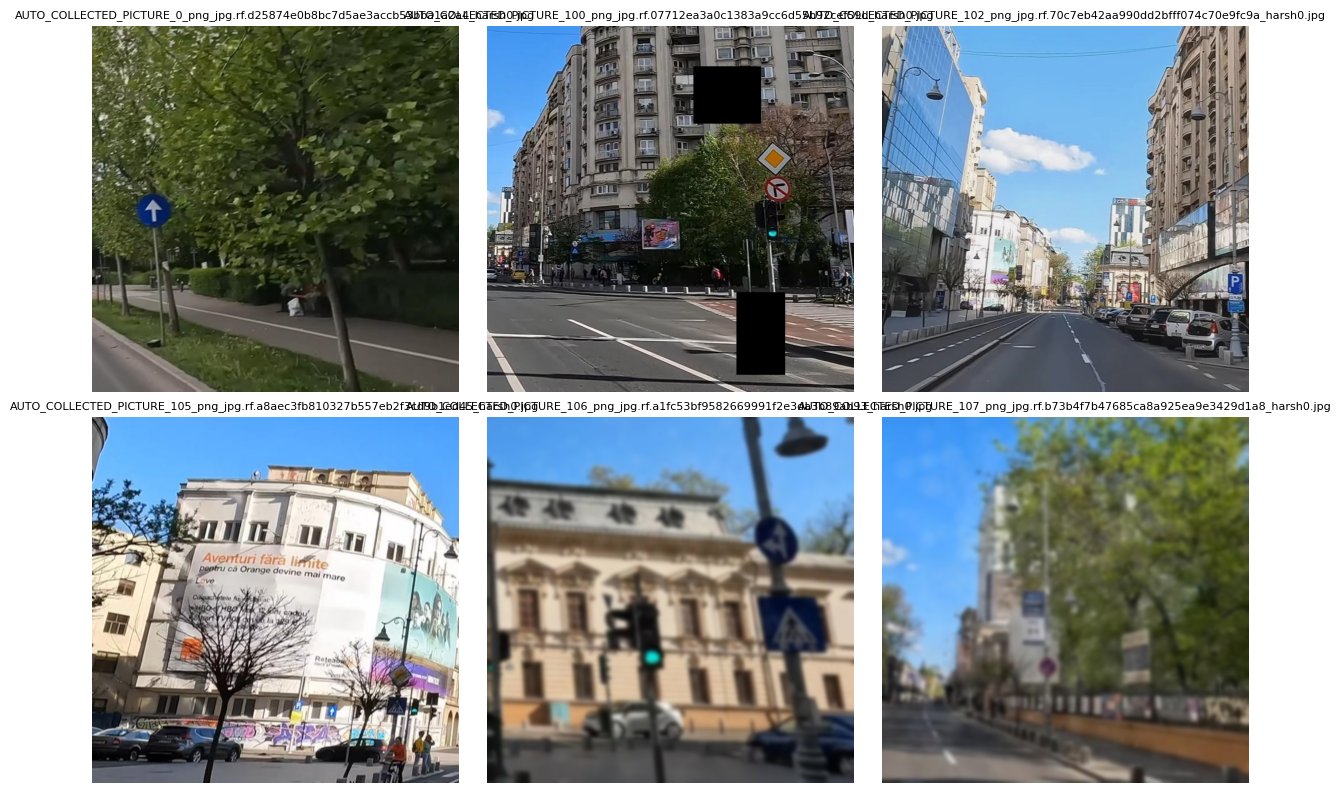

In [ ]:
# STEP 10 : Preview a Few Harsh-Condition Images (sanity check)

harsh_samples = [f for f in os.listdir(train_img_dir) if "_harsh" in f][:6]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, fname in zip(axes.flatten(), harsh_samples):
    img = cv2.imread(os.path.join(train_img_dir, fname))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(fname, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
# STEP 11 : Load Pretrained Model

model = YOLO("yolov8s.pt")  # auto-downloads if not present


In [ ]:
# STEP 12 : Train Model

results = model.train(
    data=yaml_path,
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    seed=42,
    workers=2,
    device=0,
    project=NEW_DIR,
    name="TrafficSign_TrainedModel_BigData",
    exist_ok=True,
    plots=True,
    fliplr=0.0,
    flipud=0.0,
    degrees=5,
    translate=0.10,
    scale=0.30,
    shear=2.0,
    perspective=0.0005,
    hsv_h=0.015,
    hsv_s=0.70,
    hsv_v=0.40
)


Ultralytics 8.4.132 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Diploma Major Project(DCSE691)/updated Model with 61 classes/dataset/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.

In [ ]:
# STEP : Copy dataset from Drive to local Colab disk (much faster reads)

import shutil, os

DRIVE_DATASET_DIR = "/content/drive/MyDrive/Diploma Major Project(DCSE691)/updated Model with 61 classes/dataset"
LOCAL_DATASET_DIR = "/content/dataset"

if not os.path.exists(LOCAL_DATASET_DIR):
    shutil.copytree(DRIVE_DATASET_DIR, LOCAL_DATASET_DIR)
    print("Copied dataset to local disk:", LOCAL_DATASET_DIR)
else:
    print("Local dataset already exists, skipping copy")

print(os.listdir(LOCAL_DATASET_DIR))

Copied dataset to local disk: /content/dataset
['train', 'valid', 'README.dataset.txt', 'data.yaml', 'test', 'README.roboflow.txt']


In [ ]:
import yaml

local_yaml_path = os.path.join(LOCAL_DATASET_DIR, "data.yaml")

with open(local_yaml_path, "r") as f:
    data = yaml.safe_load(f)

data["path"] = LOCAL_DATASET_DIR

with open(local_yaml_path, "w") as f:
    yaml.dump(data, f, allow_unicode=True, sort_keys=False)

print(open(local_yaml_path).read())

path: /content/dataset
names:
- No Entry for Vehicles Exceeding 5t
- No Entry for Goods Vehicles
- No Stopping or Parking
- Danger Ahead
- Caution Children
- Caution Roundabout Ahead
- Motorway
- Give Way
- One Way Traffic
- Keep Right
- Keep Right or Left
- Keep Left
- Go Straight
- Go Straight or Turn Right
- Go Straight or Turn Left
- Cyclists
- Speed Bump
- Traffic Lights
- No Overtaking
- No U-Turn
- No Right Turn
- No Left Turn
- Priority Intersection
- Parking
- Taxi Parking
- Domestic Animal Crossing
- Wild Animal Crossing
- Pedestrian Crossing
- Pedestrians
- Mandatory Cycle Path
- Maximum Weight 3.5t
- Maximum Weight 7.5t
- Speed Bumps
- Roundabout
- Dual Carriageway
- Slippery Road
- Priority Road
- Stop
- No Entry
- Bus Stop
- No Parking
- Series of Curves
- Turn Right
- Turn Right or Left
- Turn Left
- Tramway
- Road Work
- Right Curve
- Left Curve
- Speed Limit 100
- Speed Limit 10
- Speed Limit 130
- Speed Limit 20
- Speed Limit 30
- Speed Limit 40
- Speed Limit 50
- Spe

In [ ]:
import yaml

args_path = "/content/drive/MyDrive/Diploma Major Project(DCSE691)/updated Model with 61 classes/TrafficSign_TrainedModel_BigData/args.yaml"

with open(args_path, "r") as f:
    args = yaml.safe_load(f)

args["data"] = "/content/dataset/data.yaml"

with open(args_path, "w") as f:
    yaml.dump(args, f, sort_keys=False)

# verify immediately
with open(args_path, "r") as f:
    check = yaml.safe_load(f)
print("Confirmed data path now:", check["data"])

Confirmed data path now: /content/dataset/data.yaml


In [ ]:
from ultralytics import YOLO

last_checkpoint = "/content/drive/MyDrive/Diploma Major Project(DCSE691)/updated Model with 61 classes/TrafficSign_TrainedModel_BigData/weights/last.pt"

model = YOLO(last_checkpoint)  # loads weights from epoch 42

results = model.train(
    data="/content/dataset/data.yaml",   # correct local path
    epochs=100,          # keep same total; it will continue counting from where it left off in logs, though epoch numbering restarts
    imgsz=640,
    batch=16,
    patience=20,
    seed=42,
    workers=2,
    device=0,
    project="/content/drive/MyDrive/Diploma Major Project(DCSE691)/updated Model with 61 classes",
    name="TrafficSign_TrainedModel_BigData_continued",
    exist_ok=True,
    plots=True,
    fliplr=0.0,
    flipud=0.0,
    degrees=5,
    translate=0.10,
    scale=0.30,
    shear=2.0,
    perspective=0.0005,
    hsv_h=0.015,
    hsv_s=0.70,
    hsv_v=0.40
)

Ultralytics 8.4.145 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/Diploma Major Project(DCSE691)/updated Model with 61 classes/TrafficSign_TrainedModel_BigD

In [ ]:
# STEP 13 : Evaluate Model

metrics = model.val()


Ultralytics 8.4.145 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,149,191 parameters, 0 gradients, 28.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1424.4±730.7 MB/s, size: 54.2 KB)
val: Scanning /content/dataset/valid/labels.cache... 861 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 861/861 200.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 54/54 4.0it/s 13.5s
                   all        861       1673      0.879       0.85      0.892      0.754
No Entry for Vehicles Exceeding 5t          2          2          1          0      0.495      0.446
No Entry for Goods Vehicles          9          9      0.781      0.778      0.803      0.669
No Stopping or Parking         98        102      0.951      0.953      0.987      0.838
          Danger Ahead         15         15      0.863      0.867      0.897      0.747
      Caution Children     

In [ ]:
from ultralytics import YOLO

# Load your best trained model
model = YOLO(
    "/content/drive/MyDrive/Diploma Major Project(DCSE691)/updated Model with 61 classes/TrafficSign_TrainedModel_BigData_continued/weights/best.pt"
)

# Predict on test images
results = model.predict(
    source="/content/dataset/test/images",
    imgsz=640,
    conf=0.25,
    save=True,
    project="/content/drive/MyDrive/Diploma Major Project(DCSE691)/updated Model with 61 classes",
    name="Test_Prediction_Results",
    exist_ok=True
)


image 1/424 /content/dataset/test/images/AUTO_COLLECTED_PICTURE_101_png_jpg.rf.d62afcff2b05cf860e88bcc566b03b06.jpg: 640x640 2 Pedestrianss, 1 Maximum Weight 3.5t, 32.4ms
image 2/424 /content/dataset/test/images/AUTO_COLLECTED_PICTURE_121_png_jpg.rf.93680be16ce51e8f8e96052fa5dd6933.jpg: 640x640 1 Go Straight or Turn Left, 1 No Entry, 33.1ms
image 3/424 /content/dataset/test/images/AUTO_COLLECTED_PICTURE_124_png_jpg.rf.4a51a1a22bc50a5bd18f3c8e173f7974.jpg: 640x640 1 Caution Children, 18.3ms
image 4/424 /content/dataset/test/images/AUTO_COLLECTED_PICTURE_128_png_jpg.rf.cef2701ff691990bf4d927d346e61dfe.jpg: 640x640 1 Go Straight, 1 Pedestrians, 1 Priority Road, 21.2ms
image 5/424 /content/dataset/test/images/AUTO_COLLECTED_PICTURE_140_png_jpg.rf.50ffff706266b0717697fb8becd10c8c.jpg: 640x640 1 Pedestrians, 1 No Entry, 18.9ms
image 6/424 /content/dataset/test/images/AUTO_COLLECTED_PICTURE_142_png_jpg.rf.c5dbd802980b2a537defd0b1568bcf5f.jpg: 640x640 1 No Right Turn, 1 Pedestrians, 28.6ms
im

Saving new 6.png to new 6 (1).png

image 1/1 /content/new 6 (1).png: 448x640 1 Slippery Road, 12.7ms
Speed: 1.8ms preprocess, 12.7ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)


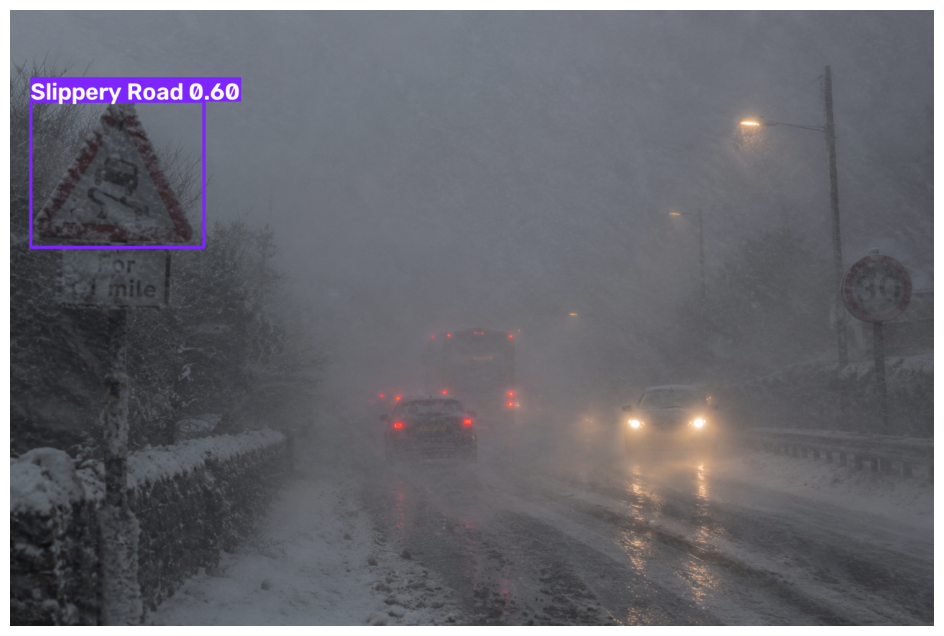

In [ ]:
# !pip install ultralytics
# from google.colab import files
# from ultralytics import YOLO
# from PIL import Image
# import matplotlib.pyplot as plt
# # STEP 5 : Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# Load your best model
model = YOLO(
    "/content/drive/MyDrive/Diploma Major Project(DCSE691)/updated Model with 61 classes/TrafficSign_TrainedModel_BigData_continued/weights/best.pt"
)

# Upload image from your computer
uploaded = files.upload()

# Get uploaded image name
image_path = next(iter(uploaded))

# Run prediction
results = model.predict(
    source=image_path,
    imgsz=640,
    conf=0.25,
    save=False
)

# Display image with bounding boxes
result_image = results[0].plot()

plt.figure(figsize=(12, 8))
plt.imshow(result_image[:, :, ::-1])  # BGR → RGB
plt.axis("off")
plt.show()

In [ ]:
# STEP 15 : Export Model

model.export(format="onnx")
